In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
df = pd.read_csv(r'D:\15\treatment_glucose.csv')

df.shape

(10, 3)

In [9]:
from scipy.stats import ttest_ind, f_oneway, chi2_contingency

import statsmodels.formula.api as smf

df = pd.read_csv(r'D:\14\diabetes.csv')

df['AgeGroup'] = pd.cut(df["Age"], 
                        bins = [20, 30, 40, 100], 
                        labels = ['20대', '30대', '40대+1'])

df['당뇨여부'] = np.where(df['Outcome'] == 1, '당뇨', '정상')

df.shape

(768, 11)

In [13]:
from scipy.stats import ttest_ind

g1 = df[df["Outcome"] == 1]['Glucose']
g2 = df[df['Outcome'] == 0]['Glucose']

t, p = ttest_ind(g1, g2, equal_var = False)

print(g1, g2)


0      148
2      183
4      137
6       78
8      197
      ... 
755    128
757    123
759    190
761    170
766    126
Name: Glucose, Length: 268, dtype: int64 1       85
3       89
5      116
7      115
10     110
      ... 
762     89
763    101
764    122
765    121
767     93
Name: Glucose, Length: 500, dtype: int64


In [14]:
print(t, p)

13.751537067396413 2.644161349540232e-36


In [16]:
b1 = df[df['Outcome'] == 1]["BMI"]
b2 = df[df["Outcome"] == 0]["BMI"]

t, p = ttest_ind(b1, b2, equal_var = False)

print('당뇨군: ', round(b1.mean(), 1), 
      '정상군: ', round(b2.mean(), 1), 
      't =', round(t, 2), 
      'p =', p)

당뇨군:  35.1 정상군:  30.3 t = 8.62 p = 6.566237624708347e-17


In [17]:
a1 = df[df['Outcome'] == 1]["Age"]
a2 = df[df["Outcome"] == 0]["Age"]

t, p = ttest_ind(a1, a2, equal_var = False)

print('당뇨군: ', round(b1.mean(), 1), 
      '정상군: ', round(b2.mean(), 1), 
      't =', round(t, 2), 
      'p =', p)

당뇨군:  35.1 정상군:  30.3 t = 6.92 p = 1.2015125273113389e-11


In [19]:
from scipy.stats import ttest_rel
tg = pd.read_csv(r'D:\15\treatment_glucose.csv')

b = tg['복용전_혈당']
a = tg['복용후_혈당']
t, p = ttest_rel(b, a)

# print(round(t, 2), round(p, 5))
print(t, 2, p, 5)

16.837458240482736 2 4.119502239623403e-08 5


In [20]:
t, p = ttest_ind(b1, b2, equal_var = False)

print(t, p)

8.619316881357946 6.566237624708347e-17


In [26]:
g1 = df[df["AgeGroup"] == '20대']['BMI']
g2 = df[df["AgeGroup"] == '30대']['BMI']
g3 = df[df["AgeGroup"] == '40대+1']['BMI']

f, p = f_oneway(g1, g2, g3)

print(round(f,2), round(p, 4))

3.34 0.0359


In [25]:
print(df["AgeGroup"].value_counts())

AgeGroup
20대      417
40대+1    194
30대      157
Name: count, dtype: int64


In [27]:
for g in ['20대', '30대', '40대+1'] :
    print(g, round(df[df['AgeGroup'] == g]['Glucose'].mean(), 1))

20대 114.2
30대 126.2
40대+1 131.1


In [34]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

d = df.dropna(subset = ['AgeGroup'])
r = pairwise_tukeyhsd(d['Glucose'], d['AgeGroup'], alpha = 0.05)

# print(r.summary())
print(r)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   20대    30대  12.0033 0.0001  5.1609 18.8457   True
   20대  40대+1  16.8868    0.0 10.5361 23.2375   True
   30대  40대+1   4.8835   0.31 -2.9611 12.7281  False
----------------------------------------------------


In [35]:
d = df.dropna(subset = ['AgeGroup'])

print(pairwise_tukeyhsd(d['BMI'], d['AgeGroup']))

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   20대    30대   1.5646 0.0853 -0.1637 3.2929  False
   20대  40대+1   1.3882 0.1052 -0.2159 2.9924  False
   30대  40대+1  -0.1763 0.9762 -2.1578 1.8051  False
---------------------------------------------------


In [37]:
df['비만여부'] = np.where(df['BMI'] >= 30, '비만', '정상')

ct = pd.crosstab(df['비만여부'], df['당뇨여부'])

chi2, p, d, e = chi2_contingency(ct)

print(ct)
print(round(chi2, 2), p)

당뇨여부   당뇨   정상
비만여부          
비만    219  253
정상     49  247
70.01 5.893192387193184e-17


In [38]:
df['고혈압'] = np.where(df['BloodPressure'] >= 80, '고혈압', '정상')

ct = pd.crosstab(df['고혈압'], df['당뇨여부'])
chi2, p, dof, e = chi2_contingency(ct)

print(chi2, p)

9.451495614333998 0.0021097699594001752


In [40]:
import numpy as np

a, b = 219, 253
c, d = 49, 247

rr = (a/(a+b)) / (c/(c+d))

or_=(a/b) / (c/d)
print('상대위험도 RR =', round(rr, 2), '오즈비 OR = ', round(or_, 2))

상대위험도 RR = 2.8 오즈비 OR =  4.36


In [46]:
df['검사양성'] = df['Glucose'] >= 140

TP = len(df[(df['검사양성']) & (df['Outcome'] == 1)])
FN = len(df[(~df['검사양성']) & (df['Outcome'] == 1)])
FP = len(df[(df['검사양성']) & (df['Outcome'] == 0)])
TN = len(df[(~df['검사양성']) & (df['Outcome'] == 0)])

sens = TP / (TP+FN)
spec = TN / (TN+FP)
ppv = TP / (TP+FP)
print('민감도: ', round(sens*100, 1), '%', 
      '특이도: ', spec*100, '%', 
      'PPV: ', round(ppv*100, 1), '%')

민감도:  50.4 % 특이도:  87.6 % PPV:  68.5 %


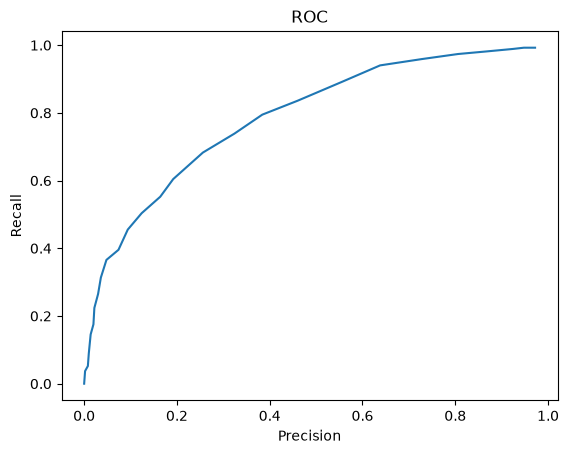

In [49]:
sens, fpr = [], []

for thr in range(70, 201, 5) :
    pos = df['Glucose'] >= thr
    
    TP = ((pos) & (df['Outcome'] == 1)).sum()
    FN = ((~pos) & (df['Outcome'] == 1)).sum()
    FP = ((pos) & (df['Outcome'] == 0)).sum()
    TN = ((~pos) & (df['Outcome'] == 0)).sum()
    
    sens.append(TP / (TP+FN))
    fpr.append(1-TN / (TN+FP))
    
plt.plot(fpr, sens)
plt.title(f'ROC')
plt.xlabel('Precision')
plt.ylabel('Recall')

auc = abs(np.trapezoid(sens, fpr))

In [52]:
for thr in [140, 170] :
    pos = df['Glucose'] >= thr
    TP = ((pos) & (df['Outcome'] == 1)).sum()
    FN = ((~pos)& (df['Outcome'] == 1)).sum()
    
    
    print(thr, f'민감도 {TP / (TP+FN): .1%}')

140 민감도  50.4%
170 민감도  22.4%


In [57]:
import statsmodels.api as sm

from statsmodels.stats.outliers_influence import variance_inflation_factor

X = sm.add_constant(df[['Glucose', 'BMI', "Age", 'BloodPressure',
                        'Pregnancies']])

for i, col in enumerate(X.columns) :
    print(col, round(variance_inflation_factor(X.values, i), 2))
    
np.random.seed(0)

df['Age_copy'] = df['Age'] + np.random.normal (0, 1, len(df))

X2 = sm.add_constant(df[['Age', 'Age_copy', "Glucose"]])
for i, col in enumerate(X2.columns) :
    print(col, round(variance_inflation_factor(X2.values, i), 2))

const 33.82
Glucose 1.13
BMI 1.13
Age 1.55
BloodPressure 1.15
Pregnancies 1.42
const 19.05
Age 141.52
Age_copy 141.56
Glucose 1.07
